# Predictive Workforce Planning Using HR Recruitment Analytics
## Step 1: Data Cleaning & Preparation

**Objective:** Clean and prepare the raw HR dataset for analysis by fixing data types,
standardizing values, handling missing data, and extracting useful time-based features.

**Dataset:** HRDataset_v14.csv — 311 employee records, 36 columns (2011–2016)

## Import Libraries

In [73]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## Load the Dataset

In [74]:
# Load the dataset
df = pd.read_csv('../data/raw/HRDataset_v14.csv', encoding='utf-8-sig')  
# encoding='utf-8-sig' handles the invisible BOM character at the start of the file

# Display basic info
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: 311 rows × 36 columns

Column Names:
['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID', 'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB', 'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus', 'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences']


## First Look at the Data

In [75]:
# Preview the first 10 rows
df.head(10)

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
5,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,Amy Dunn,11.0,LinkedIn,Exceeds,5.00,5,0,1/7/2019,0,15
6,"Andreola, Colby",10194,0,0,0,1,4,3,0,95660,...,Alex Sweetwater,10.0,LinkedIn,Fully Meets,3.04,3,4,1/2/2019,0,19
7,"Athwal, Sam",10062,0,4,1,1,5,3,0,59365,...,Ketsia Liebig,19.0,Employee Referral,Fully Meets,5.00,4,0,2/25/2019,0,19
8,"Bachiochi, Linda",10114,0,0,0,3,5,3,1,47837,...,Brannon Miller,12.0,Diversity Job Fair,Fully Meets,4.46,3,0,1/25/2019,0,4
9,"Bacong, Alejandro",10250,0,2,1,1,3,3,0,50178,...,Peter Monroe,7.0,Indeed,Fully Meets,5.00,5,6,2/18/2019,0,16


## Dataset Overview

In [76]:
# Check data types and non-null counts for every column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

## Summary Statistics

In [77]:
# Statistical summary of numeric columns
df.describe()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,Zip,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,303.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,10156.000000,0.398714,0.810289,0.434084,2.392283,4.610932,2.977492,0.093248,69020.684887,0.334405,16.845659,6555.482315,14.570957,4.110000,3.890675,1.218650,0.414791,10.237942
std,89.922189,0.490423,0.943239,0.496435,1.794383,1.083487,0.587072,0.291248,25156.636930,0.472542,6.223419,16908.396884,8.078306,0.789938,0.909241,2.349421,1.294519,5.852596
min,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,0.000000,1.000000,1013.000000,1.000000,1.120000,1.000000,0.000000,0.000000,1.000000
25%,10078.500000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55501.500000,0.000000,18.000000,1901.500000,10.000000,3.690000,3.000000,0.000000,0.000000,5.000000
50%,10156.000000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62810.000000,0.000000,19.000000,2132.000000,15.000000,4.280000,4.000000,0.000000,0.000000,10.000000
75%,10233.500000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,0.000000,72036.000000,1.000000,20.000000,2355.000000,19.000000,4.700000,5.000000,0.000000,0.000000,15.000000
max,10311.000000,1.000000,4.000000,1.000000,5.000000,6.000000,4.000000,1.000000,250000.000000,1.000000,30.000000,98052.000000,39.000000,5.000000,5.000000,8.000000,6.000000,20.000000


## See all categories in every categorical column

In [78]:
# Get all categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Total categorical columns found: {len(cat_cols)}\n")
print("=" * 50)

for col in cat_cols:
    unique_vals = df[col].unique()
    print(f"\n{col} ({len(unique_vals)} categories):")
    print(f"   {sorted([str(v) for v in unique_vals])}")

Total categorical columns found: 18


Employee_Name (311 categories):
   ['Adinolfi, Wilson  K', 'Ait Sidi, Karthikeyan   ', 'Akinkuolie, Sarah', 'Alagbe,Trina', 'Anderson, Carol ', 'Anderson, Linda  ', 'Andreola, Colby', 'Athwal, Sam', 'Bachiochi, Linda', 'Bacong, Alejandro ', 'Baczenski, Rachael  ', 'Barbara, Thomas', 'Barbossa, Hector', 'Barone, Francesco  A', 'Barton, Nader', 'Bates, Norman', 'Beak, Kimberly  ', 'Beatrice, Courtney ', 'Becker, Renee', 'Becker, Scott', 'Bernstein, Sean', 'Biden, Lowan  M', 'Billis, Helen', 'Blount, Dianna', 'Bondwell, Betsy', 'Booth, Frank', 'Boutwell, Bonalyn', 'Bozzi, Charles', 'Brill, Donna', 'Brown, Mia', 'Buccheri, Joseph  ', 'Bugali, Josephine ', 'Bunbury, Jessica', 'Burke, Joelle', 'Burkett, Benjamin ', 'Cady, Max ', 'Candie, Calvin', 'Carabbio, Judith', 'Carey, Michael  ', 'Carr, Claudia  N', 'Carter, Michelle ', "Carthy, B'rigit", 'Chace, Beatrice ', 'Champaigne, Brian', 'Chan, Lin', 'Chang, Donovan  E', 'Chigurh, Anton', 'Chivukula, Enola'

---
## Identify and Handle Missing Values

Note: Missing `DateofTermination` values are **expected** — they simply mean
the employee is still actively employed, not a data quality issue.

## Check Missing Values

In [79]:
# Count and percentage of missing values per column
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct.round(2)
})

# Show only columns that have at least one missing value
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print("Columns with missing values:")
print(missing_df)

Columns with missing values:
                   Missing Count  Missing %
DateofTermination            207      66.56
ManagerID                      8       2.57


## Handle Missing DateofTermination

In [80]:
# Fill missing DateofTermination with 'Still Employed' as a placeholder string
# Date parsing will be handled in the next section
df['DateofTermination'] = df['DateofTermination'].fillna('Still Employed')

print(f"DateofTermination nulls replaced.")
print(df['DateofTermination'].value_counts().head())

DateofTermination nulls replaced.
DateofTermination
Still Employed    207
9/24/2012           2
4/4/2014            2
5/17/2016           2
11/4/2015           2
Name: count, dtype: int64


## Handle Missing ManagerID

In [81]:
# Investigate which employees and managers have missing ManagerID or there are manager assigned or not 
print("Rows with missing ManagerID:")
print(df[df['ManagerID'].isnull()][['Employee_Name', 'Department', 'ManagerName', 'ManagerID']])

Rows with missing ManagerID:
          Employee_Name         Department     ManagerName  ManagerID
19        Becker, Scott  Production         Webster Butler        NaN
30   Buccheri, Joseph    Production         Webster Butler        NaN
44    Chang, Donovan  E  Production         Webster Butler        NaN
88      Fancett, Nicole  Production         Webster Butler        NaN
135     Hutter, Rosalie  Production         Webster Butler        NaN
177   Manchester, Robyn  Production         Webster Butler        NaN
232     Rivera, Haley    Production         Webster Butler        NaN
251      Sewkumar, Nori  Production         Webster Butler        NaN


In [86]:
print(df['ManagerID'].unique())

[22.  4. 20. 16. 39. 11. 10. 19. 12.  7. 14. 18. nan  3.  2.  1. 17.  5.
 21.  6. 15. 13.  9. 30.]


In [87]:
# Get all employee IDs and manager names where ManagerID = 'Webster Butler'
webster = df[df['ManagerName'] == 'Webster Butler'][['EmpID', 'ManagerID', 'ManagerName']].drop_duplicates()
print(webster)

     EmpID  ManagerID     ManagerName
4    10069       39.0  Webster Butler
19   10277        NaN  Webster Butler
30   10184        NaN  Webster Butler
44   10154        NaN  Webster Butler
65   10070       39.0  Webster Butler
88   10136        NaN  Webster Butler
89   10189       39.0  Webster Butler
105  10283       39.0  Webster Butler
124  10097       39.0  Webster Butler
135  10214        NaN  Webster Butler
151  10166       39.0  Webster Butler
174  10004       39.0  Webster Butler
177  10077        NaN  Webster Butler
198  10215       39.0  Webster Butler
206  10078       39.0  Webster Butler
214  10286       39.0  Webster Butler
232  10011        NaN  Webster Butler
251  10071        NaN  Webster Butler
276  10221       39.0  Webster Butler
280  10268       39.0  Webster Butler
300  10072       39.0  Webster Butler


In [88]:
# Get all employees and managers where ManagerID = 39
print(df[df['ManagerID'] == 39][['EmpID', 'ManagerID', 'ManagerName']].drop_duplicates('EmpID'))


     EmpID  ManagerID     ManagerName
4    10069       39.0  Webster Butler
65   10070       39.0  Webster Butler
89   10189       39.0  Webster Butler
105  10283       39.0  Webster Butler
124  10097       39.0  Webster Butler
151  10166       39.0  Webster Butler
174  10004       39.0  Webster Butler
198  10215       39.0  Webster Butler
206  10078       39.0  Webster Butler
214  10286       39.0  Webster Butler
276  10221       39.0  Webster Butler
280  10268       39.0  Webster Butler
300  10072       39.0  Webster Butler


In [89]:
# Fill missing ManagerID with 39 
# We use 39 because other ManageID columns with ManagerName 'Webster Butler' is 39 and there is no any ManagerName relevant to the ManagerID=39
df['ManagerID'] = df['ManagerID'].fillna(39).astype(int)

print(f"Remaining ManagerID nulls: {df['ManagerID'].isnull().sum()}")
print("ManagerID dtype:", df['ManagerID'].dtype)

Remaining ManagerID nulls: 0
ManagerID dtype: int64


---
## Parse and Fix Date Columns

`DateofHire` and `DateofTermination` are currently stored as plain text strings.
Need to convert them to proper datetime objects so we can do time-based analysis,
extract year/month, and calculate how long employees stayed.

## Parse DateofHire

In [90]:
# Convert DateofHire to datetime
df['DateofHire'] = pd.to_datetime(df['DateofHire'], format='mixed', errors='coerce')

print("DateofHire dtype:", df['DateofHire'].dtype)
print("Sample values:")
print(df['DateofHire'].head())
print(f"\nAny nulls after parsing: {df['DateofHire'].isnull().sum()}")

DateofHire dtype: datetime64[ns]
Sample values:
0   2011-07-05
1   2015-03-30
2   2011-07-05
3   2008-01-07
4   2011-07-11
Name: DateofHire, dtype: datetime64[ns]

Any nulls after parsing: 0


## Parse DateofTermination

In [91]:
# Convert DateofTermination (skip the 'Still Employed' placeholders)
df['DateofTermination'] = pd.to_datetime(
    df['DateofTermination'].replace('Still Employed', np.nan),
    format='mixed',
    errors='coerce'
)

print("DateofTermination dtype:", df['DateofTermination'].dtype)
print(f"Active employees (NaT): {df['DateofTermination'].isnull().sum()}")
print(f"Terminated employees (with date): {df['DateofTermination'].notna().sum()}")

DateofTermination dtype: datetime64[ns]
Active employees (NaT): 207
Terminated employees (with date): 104


## Extract Time Features

In [92]:
# Extract year and month from DateofHire (for trend analysis)
df['HireYear']  = df['DateofHire'].dt.year
df['HireMonth'] = df['DateofHire'].dt.month
df['HireMonthName'] = df['DateofHire'].dt.strftime('%b')  # (Jan, Feb, ......)

# Calculate Tenure in years (for active employees, use today as end date)
reference_date = pd.Timestamp('2019-01-01')  # approximate last review date in dataset
df['TenureYears'] = (
    df['DateofTermination'].fillna(reference_date) - df['DateofHire']
).dt.days / 365.25

df['TenureYears'] = df['TenureYears'].round(2)

print("New columns added: HireYear, HireMonth, HireMonthName, TenureYears")
print(df[['DateofHire', 'HireYear', 'HireMonth', 'HireMonthName', 'TenureYears']].head(8))

New columns added: HireYear, HireMonth, HireMonthName, TenureYears
  DateofHire  HireYear  HireMonth HireMonthName  TenureYears
0 2011-07-05      2011          7           Jul         7.49
1 2015-03-30      2015          3           Mar         1.22
2 2011-07-05      2011          7           Jul         1.22
3 2008-01-07      2008          1           Jan        10.98
4 2011-07-11      2011          7           Jul         5.16
5 2012-01-09      2012          1           Jan         6.98
6 2014-11-10      2014         11           Nov         4.14
7 2013-09-30      2013          9           Sep         5.25


---
## Standardize Text Columns

Text columns often have inconsistent formatting — extra spaces, mixed casing, or slight spelling variations. 
These cause the same value to be counted as multiple different categories in analysis.

## Check Department Name Issues

In [93]:
# Reveal the raw department values including any hidden spaces
print("Raw Department values (with hidden spaces visible):")
for dept in df['Department'].unique():
    print(repr(dept))  # repr() shows spaces and special characters clearly

Raw Department values (with hidden spaces visible):
'Production       '
'IT/IS'
'Software Engineering'
'Admin Offices'
'Sales'
'Executive Office'


## Clean All Text Columns

In [94]:
# List of text columns to clean
text_columns = ['Department', 'Position', 'RecruitmentSource', 
                'TermReason', 'EmploymentStatus', 'ManagerName',
                'Sex', 'MaritalDesc', 'RaceDesc', 'PerformanceScore']

for col in text_columns:
    df[col] = df[col].str.strip()        # Remove leading/trailing spaces
    df[col] = df[col].str.title()        # Standardize to Title Case

print("Text columns cleaned.")
print("\nDepartment values after cleaning:")
print(df['Department'].unique())

Text columns cleaned.

Department values after cleaning:
['Production' 'It/Is' 'Software Engineering' 'Admin Offices' 'Sales'
 'Executive Office']


## Fix IT/IS Department Name

In [95]:
# .title() incorrectly changed 'IT/IS' to 'It/Is' - fix it
df['Department'] = df['Department'].replace('It/Is', 'IT/IS')

print("Department values after manual fix:")
print(df['Department'].unique())

Department values after manual fix:
['Production' 'IT/IS' 'Software Engineering' 'Admin Offices' 'Sales'
 'Executive Office']


## Verify TermReason Consistency

In [96]:
# Check all unique TermReason values after cleaning
print("Unique Termination Reasons:")
print(df['TermReason'].value_counts())

Unique Termination Reasons:
TermReason
N/A-Stillemployed                   207
Another Position                     20
Unhappy                              14
More Money                           11
Career Change                         9
Hours                                 8
Attendance                            7
Return To School                      5
Relocation Out Of Area                5
Performance                           4
Military                              4
Retiring                              4
No-Call, No-Show                      4
Maternity Leave - Did Not Return      3
Medical Issues                        3
Learned That He Is A Gangster         1
Fatal Attraction                      1
Gross Misconduct                      1
Name: count, dtype: int64


## Fix TermReason Inconsistency

In [97]:
# .title() broke 'N/A-StillEmployed' -> 'N/A-Stillemployed'
# Fix it back to a clean, readable value
df['TermReason'] = df['TermReason'].replace('N/A-Stillemployed', 'Still Employed')

print("TermReason unique values after fix:")
print(df['TermReason'].value_counts())

TermReason unique values after fix:
TermReason
Still Employed                      207
Another Position                     20
Unhappy                              14
More Money                           11
Career Change                         9
Hours                                 8
Attendance                            7
Return To School                      5
Relocation Out Of Area                5
Performance                           4
Military                              4
Retiring                              4
No-Call, No-Show                      4
Maternity Leave - Did Not Return      3
Medical Issues                        3
Learned That He Is A Gangster         1
Fatal Attraction                      1
Gross Misconduct                      1
Name: count, dtype: int64


---
## Check for Duplicates and Salary Outliers

Duplicate records inflate hire counts and distort trends.
Salary outliers (if extreme) can skew any budget-related analysis.

## Check for Duplicates

In [98]:
# Check for fully duplicated rows
duplicate_count = df.duplicated().sum()
print(f"Fully duplicated rows: {duplicate_count}")

# Check for duplicate Employee IDs
duplicate_ids = df['EmpID'].duplicated().sum()
print(f"Duplicate EmpIDs: {duplicate_ids}")

Fully duplicated rows: 0
Duplicate EmpIDs: 0


## Check Salary Outliers

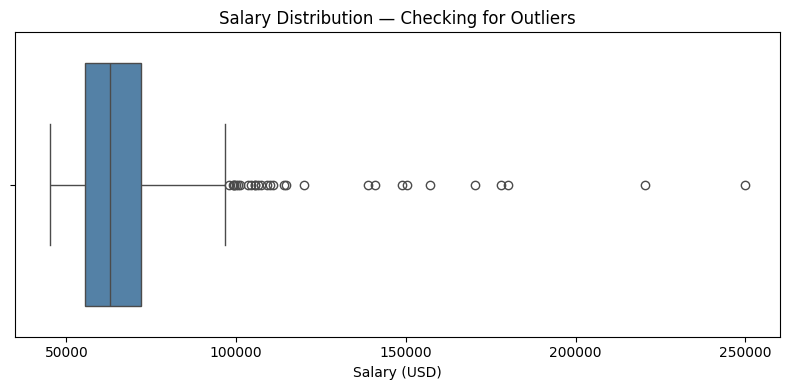

count       311.000000
mean      69020.684887
std       25156.636930
min       45046.000000
25%       55501.500000
50%       62810.000000
75%       72036.000000
max      250000.000000
Name: Salary, dtype: float64


In [99]:
# Visualize salary distribution with a boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Salary'], color='steelblue')
plt.title('Salary Distribution — Checking for Outliers')
plt.xlabel('Salary (USD)')
plt.tight_layout()
plt.show()

# Print salary stats
print(df['Salary'].describe())

---
## Create a Clean Employment Status Flag

We'll add a simple binary column `IsActive` (1 = still employed, 0 = terminated)
to make filtering easier throughout the rest of the analysis.

## Add IsActive Column

In [100]:
# Create IsActive flag: 1 if no termination date, 0 if terminated
df['IsActive'] = df['DateofTermination'].isnull().astype(int)

print("Employment Status Distribution:")
print(df['IsActive'].value_counts().rename({1: 'Active', 0: 'Terminated'}))

Employment Status Distribution:
IsActive
Active        207
Terminated    104
Name: count, dtype: int64


---
## Fix ID Column Data Types

ID columns stored as integers fall into three categories:
- **True identifiers** (EmpID, ManagerID, PositionID, DeptID) — should be strings, never used in math
- **Binary flags** (MarriedID, Termd, FromDiversityJobFairID) — keep as int, used for 0/1 calculations  
- **Encoded categories** (GenderID, EmpStatusID, PerfScoreID, MaritalStatusID) — convert to string to prevent accidental arithmetic

In [101]:
# True identifier columns — convert to string (no math should ever be done on these)
id_cols_to_string = ['EmpID', 'ManagerID', 'PositionID', 'DeptID',
                     'GenderID', 'EmpStatusID', 'PerfScoreID', 'MaritalStatusID']

for col in id_cols_to_string:
    df[col] = df[col].astype(str)

# Binary flag columns — keep as int (0/1 flags, valid for percentage calculations)
# MarriedID, FromDiversityJobFairID, Termd — no changes needed

print("Updated dtypes for ID columns:")
all_id_cols = ['EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID', 'EmpStatusID',
               'DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'PositionID', 'ManagerID']

for col in all_id_cols:
    print(f"  {col:25s} → {df[col].dtype}")

Updated dtypes for ID columns:
  EmpID                     → object
  MarriedID                 → int64
  MaritalStatusID           → object
  GenderID                  → object
  EmpStatusID               → object
  DeptID                    → object
  PerfScoreID               → object
  FromDiversityJobFairID    → int64
  PositionID                → object
  ManagerID                 → object


## See all categories in every categorical column

In [102]:
# Get all categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Total categorical columns found: {len(cat_cols)}\n")
print("=" * 50)

for col in cat_cols:
    unique_vals = df[col].unique()
    print(f"\n{col} ({len(unique_vals)} categories):")
    print(f"   {sorted([str(v) for v in unique_vals])}")

Total categorical columns found: 25


Employee_Name (311 categories):
   ['Adinolfi, Wilson  K', 'Ait Sidi, Karthikeyan   ', 'Akinkuolie, Sarah', 'Alagbe,Trina', 'Anderson, Carol ', 'Anderson, Linda  ', 'Andreola, Colby', 'Athwal, Sam', 'Bachiochi, Linda', 'Bacong, Alejandro ', 'Baczenski, Rachael  ', 'Barbara, Thomas', 'Barbossa, Hector', 'Barone, Francesco  A', 'Barton, Nader', 'Bates, Norman', 'Beak, Kimberly  ', 'Beatrice, Courtney ', 'Becker, Renee', 'Becker, Scott', 'Bernstein, Sean', 'Biden, Lowan  M', 'Billis, Helen', 'Blount, Dianna', 'Bondwell, Betsy', 'Booth, Frank', 'Boutwell, Bonalyn', 'Bozzi, Charles', 'Brill, Donna', 'Brown, Mia', 'Buccheri, Joseph  ', 'Bugali, Josephine ', 'Bunbury, Jessica', 'Burke, Joelle', 'Burkett, Benjamin ', 'Cady, Max ', 'Candie, Calvin', 'Carabbio, Judith', 'Carey, Michael  ', 'Carr, Claudia  N', 'Carter, Michelle ', "Carthy, B'rigit", 'Chace, Beatrice ', 'Champaigne, Brian', 'Chan, Lin', 'Chang, Donovan  E', 'Chigurh, Anton', 'Chivukula, Enola'

---
## Final Review of Cleaned Dataset

Let's do a final check to confirm the dataset is clean, consistent,
and ready for exploratory analysis in Step 2.

## Final Check

In [103]:
print("=" * 50)
print("CLEANED DATASET SUMMARY")
print("=" * 50)
print(f"Total Records     : {df.shape[0]}")
print(f"Total Columns     : {df.shape[1]}")
print(f"Active Employees  : {df['IsActive'].sum()}")
print(f"Terminated        : {(df['IsActive'] == 0).sum()}")
print(f"Hire Year Range   : {df['HireYear'].min()} – {df['HireYear'].max()}")
print(f"Departments       : {sorted(df['Department'].unique())}")

# Exclude DateofTermination from null check (NaT = active employee, not missing data)
cols_to_check = df.columns.difference(['DateofTermination'])
remaining_nulls = df[cols_to_check].isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]

if remaining_nulls.empty:
    print("\nNo unexpected nulls remaining in the dataset.")
else:
    print("\nUnexpected nulls remaining:")
    print(remaining_nulls)

print(f"\nNote: DateofTermination has {df['DateofTermination'].isnull().sum()} NaT values")
print("      — these are EXPECTED (represent currently active employees, not missing data)")

CLEANED DATASET SUMMARY
Total Records     : 311
Total Columns     : 41
Active Employees  : 207
Terminated        : 104
Hire Year Range   : 2006 – 2018
Departments       : ['Admin Offices', 'Executive Office', 'IT/IS', 'Production', 'Sales', 'Software Engineering']

No unexpected nulls remaining in the dataset.

Note: DateofTermination has 207 NaT values
      — these are EXPECTED (represent currently active employees, not missing data)


## Preview Cleaned Data

In [104]:
# Final look at cleaned dataframe with new columns
df[['Employee_Name', 'Department', 'DateofHire', 'HireYear', 
    'HireMonth', 'TenureYears', 'EmploymentStatus', 
    'IsActive', 'RecruitmentSource']].head(10)

,Employee_Name,Department,DateofHire,HireYear,HireMonth,TenureYears,EmploymentStatus,IsActive,RecruitmentSource
0,"Adinolfi, Wilson K",Production,2011-07-05,2011,7,7.49,Active,1,Linkedin
1,"Ait Sidi, Karthikeyan",IT/IS,2015-03-30,2015,3,1.22,Voluntarily Terminated,0,Indeed
2,"Akinkuolie, Sarah",Production,2011-07-05,2011,7,1.22,Voluntarily Terminated,0,Linkedin
3,"Alagbe,Trina",Production,2008-01-07,2008,1,10.98,Active,1,Indeed
4,"Anderson, Carol",Production,2011-07-11,2011,7,5.16,Voluntarily Terminated,0,Google Search
5,"Anderson, Linda",Production,2012-01-09,2012,1,6.98,Active,1,Linkedin
6,"Andreola, Colby",Software Engineering,2014-11-10,2014,11,4.14,Active,1,Linkedin
7,"Athwal, Sam",Production,2013-09-30,2013,9,5.25,Active,1,Employee Referral
8,"Bachiochi, Linda",Production,2009-07-06,2009,7,9.49,Active,1,Diversity Job Fair
9,"Bacong, Alejandro",IT/IS,2015-01-05,2015,1,3.99,Active,1,Indeed


## Save Cleaned Dataset

In [105]:
# Save to the correct project folder
df.to_csv('../data/processed/HRDataset_Cleaned.csv', index=False)
print("Cleaned dataset saved to '../data/processed/HRDataset_Cleaned.csv'")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Cleaned dataset saved to '../data/processed/HRDataset_Cleaned.csv'
   Shape: 311 rows × 41 columns


---
## Step 1 Completed — Data Cleaning Summary

**Dataset:** HRDataset_v14.csv &nbsp;|&nbsp; **Records:** 311 &nbsp;|&nbsp; 
**Original Columns:** 36 &nbsp;|&nbsp; **Final Columns:** 41 &nbsp;|&nbsp; 
**Hire Year Range:** 2006 – 2018

---

### 🔹 1. Data Loading
| Detail | Value |
|---|---|
| Source file | `HRDataset_v14.csv` |
| Encoding used | `utf-8-sig` (handles invisible BOM character) |
| Rows loaded | 311 |
| Columns loaded | 36 |

---

### 🔹 2. Missing Values
| Column | Missing Count | Action Taken |
|---|---|---|
| `DateofTermination` | 207 (66.56%) | Expected — NaT means actively employed, not a data error |
| `ManagerID` | 8 (2.57%) | Investigated — all 8 belonged to Webster Butler, filled with `39` |

---

### 🔹 3. Date Column Parsing
| Column | Before | After | Nulls After Parsing |
|---|---|---|---|
| `DateofHire` | `object` (string) | `datetime64[ns]` | 0 |
| `DateofTermination` | `object` (string) | `datetime64[ns]` | 207 (NaT = active employees) |

---

### 🔹 4. New Columns Added
| New Column | Description |
|---|---|
| `HireYear` | Year extracted from `DateofHire` |
| `HireMonth` | Month number extracted from `DateofHire` |
| `HireMonthName` | Month name (Jan, Feb, ...) extracted from `DateofHire` |
| `TenureYears` | Years employed — hire to termination (or 2019-01-01 for active employees) |
| `IsActive` | Binary flag — `1` = Active, `0` = Terminated |

---

### 🔹 5. Text Column Standardization
| Action | Columns Affected |
|---|---|
| Stripped whitespace (`.strip()`) | `Department`, `Position`, `RecruitmentSource`, `TermReason`, `EmploymentStatus`, `ManagerName`, `Sex`, `MaritalDesc`, `RaceDesc`, `PerformanceScore` |
| Title Case applied (`.title()`) | Same 10 columns above |
| Manual fix — `It/Is` → `IT/IS` | `Department` (`.title()` broke the acronym) |
| Manual fix — `N/A-Stillemployed` → `Still Employed` | `TermReason` (`.title()` broke the casing) |

---

### 🔹 6. Duplicates Check
| Check | Result |
|---|---|
| Fully duplicated rows | 0 |
| Duplicate `EmpID` values | 0 |

---

### 🔹 7. Salary Outliers
| Metric | Value |
|---|---|
| Min salary | $45,046 |
| Max salary | $250,000 |
| Mean salary | $69,021 |
| Median salary | $62,810 |
| Decision | Outlier noted and kept — likely a senior executive salary |

---

### 🔹 8. ID Column Data Type Fixes
| Column | Type Before | Type After | Reason |
|---|---|---|---|
| `EmpID` | `int64` | `object` | Identifier — no math needed |
| `ManagerID` | `float64` | `object` | Identifier — no math needed |
| `PositionID` | `int64` | `object` | Identifier — no math needed |
| `DeptID` | `int64` | `object` | Identifier — no math needed |
| `GenderID` | `int64` | `object` | Encoded category — text column `Sex` already exists |
| `EmpStatusID` | `int64` | `object` | Encoded category — text column `EmploymentStatus` already exists |
| `PerfScoreID` | `int64` | `object` | Encoded category — text column `PerformanceScore` already exists |
| `MaritalStatusID` | `int64` | `object` | Encoded category — text column `MaritalDesc` already exists |
| `MarriedID` | `int64` | `int64` *(kept)* | Binary flag — useful for percentage calculations |
| `FromDiversityJobFairID` | `int64` | `int64` *(kept)* | Binary flag — useful for percentage calculations |
| `Termd` | `int64` | `int64` *(kept)* | Binary flag — useful for percentage calculations |

---

### 🔹 Final Dataset State
| Metric | Value |
|---|---|
| Total records | 311 |
| Total columns | 41 (36 original + 5 new) |
| Active employees | 207 |
| Terminated employees | 104 |
| Departments | Admin Offices, Executive Office, IT/IS, Production, Sales, Software Engineering |
| Remaining unexpected nulls | **None** |
| Output file | `../data/processed/HRDataset_Cleaned.csv` |

---
**Next Step → Notebook 02: Exploratory Data Analysis (EDA)**